# Confidence-interval plots

Loads training rewards from either format:

- `training_rewards.npz`: a `rewards` array plus an optional matching `seeds` array;
- `training_rewards.npy`: a legacy raw reward array.

Reward arrays may have shape `[n_iterations]` or `[n_seeds, n_iterations]`; one-dimensional data is promoted to one seed. The loader prefers NPZ when both files exist. A 95% CI band is drawn when multiple seeds are available, while a single curve is plotted without a band.

Edit the configuration cell or set `CI_RUN_DIR`, `CI_REWARDS_FILE`, `CI_ENV_ID`, and `CI_TITLE` before headless execution. `CI_REWARDS_FILE` may name either an NPY or NPZ file. For an exact selection of several files, use `analysis.py ci`.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np

repo_root = Path.cwd().resolve()
if not (repo_root / "utils.py").is_file():
    repo_root = repo_root.parent
if not (repo_root / "utils.py").is_file():
    raise FileNotFoundError("Could not locate the repository root containing utils.py")

sys.path.insert(0, str(repo_root))
from utils import plot_seed_ci

In [2]:
def resolve_rewards_path(run_dir, reward_file=None):
    run_dir = Path(run_dir).expanduser().resolve()
    if reward_file:
        path = Path(reward_file).expanduser()
        if not path.is_absolute():
            run_relative = run_dir / path
            path = run_relative if run_relative.exists() else repo_root / path
        path = path.resolve()
        if not path.is_file():
            raise FileNotFoundError(f"Reward file does not exist: {path}")
        return path

    candidates = [
        run_dir / "training_rewards.npz",
        run_dir / "training_rewards.npy",
    ]
    existing = [path for path in candidates if path.is_file()]
    if not existing:
        raise FileNotFoundError(
            f"No training_rewards.npz or training_rewards.npy found in {run_dir}"
        )
    if len(existing) > 1:
        print(f"Found both formats; preferring {existing[0].name}")
    return existing[0]


def load_training_rewards(path, seeds_override=None):
    path = Path(path)
    suffix = path.suffix.lower()
    seeds = None

    if suffix == ".npz":
        with np.load(path, allow_pickle=False) as archive:
            if "rewards" not in archive.files:
                raise ValueError(
                    f"{path} is not a training-reward archive: expected key "
                    f"'rewards', found {archive.files}"
                )
            curves = np.array(archive["rewards"], dtype=np.float64, copy=True)
            if "seeds" in archive.files:
                seeds = np.array(archive["seeds"], copy=True)
    elif suffix == ".npy":
        curves = np.array(
            np.load(path, allow_pickle=False),
            dtype=np.float64,
            copy=True,
        )
    else:
        raise ValueError(
            f"Unsupported reward file extension {suffix!r}; use .npy or .npz"
        )

    if curves.ndim == 1:
        curves = curves[np.newaxis, :]
    if curves.ndim != 2 or curves.shape[1] == 0:
        raise ValueError(
            f"Rewards must have shape [iterations] or [seeds, iterations], "
            f"got {curves.shape}"
        )
    if not np.all(np.isfinite(curves)):
        raise ValueError(f"Rewards contain NaN or infinite values: {path}")

    if seeds_override is not None:
        seeds = np.asarray(seeds_override)
    if seeds is not None:
        if seeds.ndim != 1 or seeds.shape[0] != curves.shape[0]:
            raise ValueError(
                f"Expected one seed ID per curve; "
                f"seeds={seeds.shape}, curves={curves.shape}"
            )
        labels = [f"seed {seed}" for seed in seeds]
    else:
        labels = [f"curve {index}" for index in range(curves.shape[0])]

    return curves, seeds, labels

In [3]:
# A relative CI_RUN_DIR is resolved from the repository root.
run_dir_setting = os.environ.get("CI_RUN_DIR", "runs/Swimmer/gpomdp")
run_dir = Path(run_dir_setting).expanduser()
if not run_dir.is_absolute():
    run_dir = repo_root / run_dir
run_dir = run_dir.resolve()

# Leave unset to auto-detect training_rewards.npz or training_rewards.npy.
reward_file = os.environ.get("CI_REWARDS_FILE") or None

# Legacy NPY files do not contain seed IDs. Set this manually when known.
seeds_override = None

try:
    inferred_env_id = run_dir.relative_to(repo_root / "runs").parts[0]
except (ValueError, IndexError):
    inferred_env_id = run_dir.name
env_id = os.environ.get("CI_ENV_ID", inferred_env_id)
plot_title = os.environ.get("CI_TITLE", f"Training reward across seeds - {env_id}")

loaded /Users/adelella/Documents/Useful/More/pj/vanilla-policy-gradient/runs/Swimmer/gpomdp/training_rewards.npy
curves: (1, 2000) (n_seeds, n_iterations); seeds: not stored
  curve 0: final = 274.88, max = 282.77
Saved CI plot: /Users/adelella/Documents/Useful/More/pj/vanilla-policy-gradient/runs/Swimmer/gpomdp/training_rewards_ci.png
saved /Users/adelella/Documents/Useful/More/pj/vanilla-policy-gradient/runs/Swimmer/gpomdp/training_rewards_ci.png


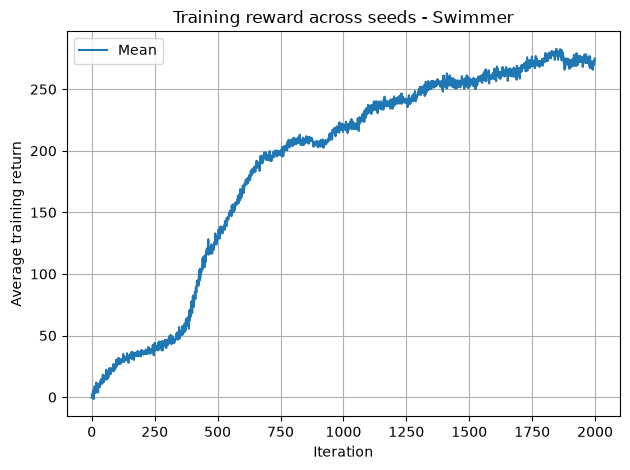

In [4]:
rewards_path = resolve_rewards_path(run_dir, reward_file)
curves, seeds, labels = load_training_rewards(rewards_path, seeds_override)
seed_description = seeds.tolist() if seeds is not None else "not stored"
print(f"loaded {rewards_path}")
print(
    f"curves: {curves.shape} (n_seeds, n_iterations); "
    f"seeds: {seed_description}"
)

# Per-curve final performance makes under/over-performing runs visible.
for label, curve in zip(labels, curves):
    print(f"  {label}: final = {curve[-1]:.2f}, max = {curve.max():.2f}")

save_path = run_dir / "training_rewards_ci.png"
plot_seed_ci(
    curves,
    save_path=str(save_path),
    title=plot_title,
)
print(f"saved {save_path}")